In [10]:
import numpy as np
from os import listdir

from AutoencoderAPI.utils.decibels import file_name_table
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [11]:
decibel_dict= file_name_table('Datasets/NIST (250) test/', 250, (67,71))

In [12]:
signal_size = 250
path_test = 'Datasets/NIST (250) test/'#NIST (800)/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

{'files': {'dataset': 'Datasets/NIST (250) train', 'path_save': 'AutoencoderLog/', 'input_dimension': 250}, 'network': {'network_type': 'generic', 'activation_list': ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'], 'layer_list': [250, 50, 50, 1, 50, 50, 250], 'layer_type': 'Linear', 'bw_cst': [0.01]}, 'train': {'optimizer': 'Adam', 'criterion': 'TripletMSE', 'alpha': 0.002, 'epochs': 10, 'skip_elements': 1, 'learning_rate': 1e-06}}


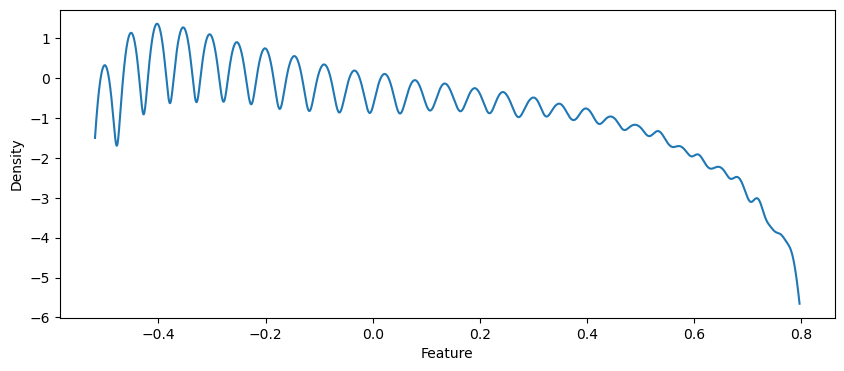

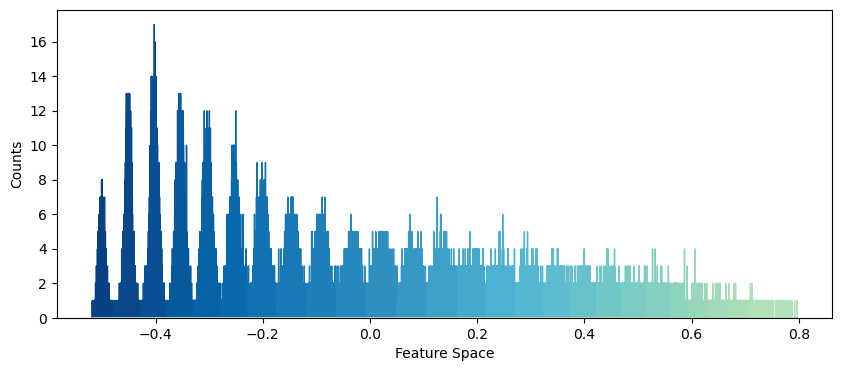

In [13]:
ak = autoencoder_kernelDensity("AutoencoderLog/run-2023-10-10-09-19/fold 0")
ak.fit(X_train, plot_cluster=True, plot_traces=False, plot_density=True, bw_cst=[0.008], flip=False, filter_input=True)

In [14]:
decibel = []
g2 = []
average = []
labels = []
for key in decibel_dict.keys():
    X = decibel_dict[key]
    labels_ = ak.get_label(X)
    labels = np.append(labels, labels_)
    decibel.append(float(key))
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

Text(0, 0.5, 'Second Order Correlation')

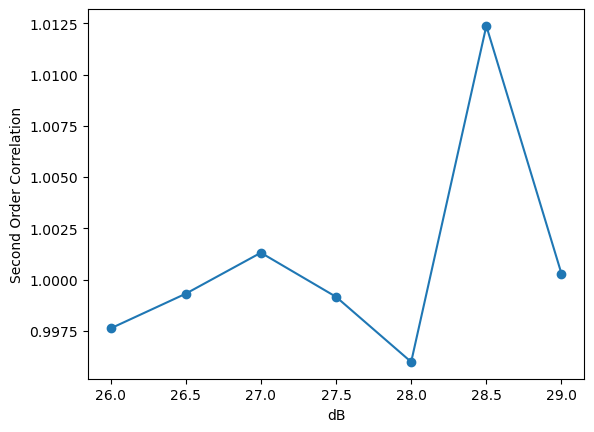

In [15]:
plt.plot(decibel, g2, marker='o')
plt.xlabel("dB")
plt.ylabel("Second Order Correlation")

In [16]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB * cst )

[9.43619976e+08 2.98951927e-01]


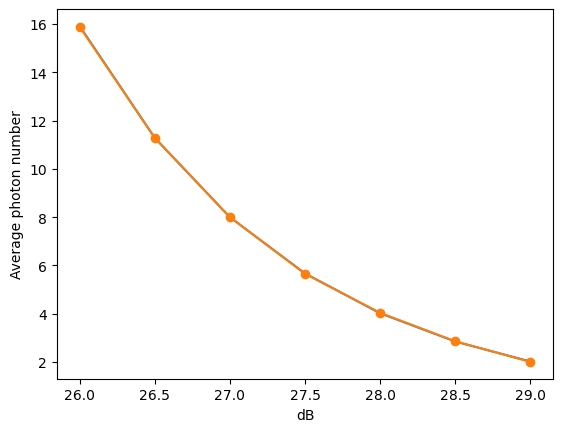

In [17]:
popt, pcov = curve_fit(function, decibel[-5:], average[-5:], 
                       bounds=([0, -10], [1e14, 100]),
                       p0=[4,0.1])
plt.plot(decibel, function(decibel, *popt))
plt.plot(decibel, average,marker='o' )
plt.xlabel("dB")
plt.ylabel("Average photon number")
print(popt)

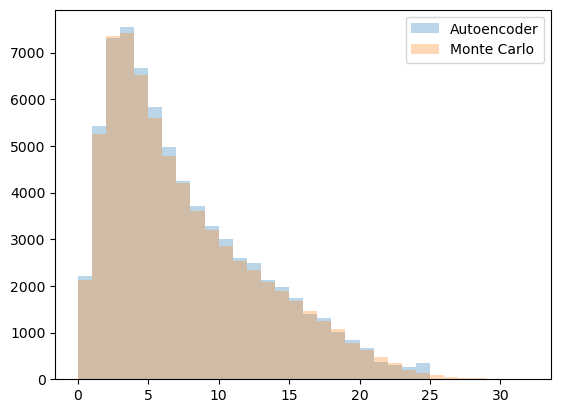

: 

In [18]:
import numpy.random as npr

decibel = np.arange(26,29.5,0.5)
average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average])
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Autoencoder')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()